# 지하철이용정보분석
- https://data.busan.go.kr/bdip/
- 승하차 인원정보 검색하기
- 일별역별시간대별승하차 파일
- 최신 CSV 파일로 저장

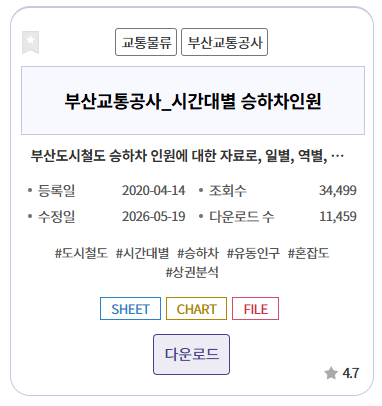

In [18]:
import pandas as pd
file_path = './dataset/일별역별시간대별승하차202604.csv'
df = pd.read_csv(file_path, encoding="EUC-KR")
df[df['역명']=='경성대부경대']

,역번호,역명,년월일,요일,구분,합계,01시-02시,02시-03시,03시-04시,04시-05시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시-01시
3162,212,경성대부경대,2026-01-01,목,승차,7668,0,0,0,6,...,567,676,605,485,350,341,312,234,132,11
3163,212,경성대부경대,2026-01-01,목,하차,7722,0,0,0,0,...,542,586,584,615,494,379,529,428,259,79
3164,212,경성대부경대,2026-01-02,금,승차,14210,0,0,0,1,...,1108,1216,1323,1403,716,595,504,421,266,14
3165,212,경성대부경대,2026-01-02,금,하차,14807,0,0,0,0,...,886,1020,1276,1931,983,608,649,603,379,84
3166,212,경성대부경대,2026-01-03,토,승차,11382,0,0,0,1,...,947,1108,998,736,529,465,395,353,225,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23275,212,경성대부경대,2026-04-28,화,하차,23411,0,0,0,1,...,945,1176,1501,2150,977,743,762,810,345,115
23276,212,경성대부경대,2026-04-29,수,승차,22434,0,0,0,0,...,1781,2648,2718,2024,960,848,738,591,414,13
23277,212,경성대부경대,2026-04-29,수,하차,22814,3,0,0,0,...,947,1156,1501,2110,1001,770,710,720,559,94
23278,212,경성대부경대,2026-04-30,목,승차,25420,0,0,0,3,...,2015,3005,3147,2484,1196,1031,948,676,399,13


In [2]:
import pandas as pd
file_path = './dataset/일별역별시간대별승하차202604.csv'
df = pd.read_csv(file_path, encoding="EUC-KR")

columns0 = ['num','name','date','week','type','total']
time_col = [f"{n:02}~{n+1:02}H" for n in range(1,24)]
last_col = ['24~01H']
columns = columns0 + time_col + last_col
df.columns = columns
df = df.loc[:,'name':'total']
df

,name,date,week,type,total
0,다대포해수욕장,2026-01-01,목,승차,7526
1,다대포해수욕장,2026-01-01,목,하차,7357
2,다대포해수욕장,2026-01-02,금,승차,4135
3,다대포해수욕장,2026-01-02,금,하차,3177
4,다대포해수욕장,2026-01-03,토,승차,4114
...,...,...,...,...,...
26875,안평,2026-04-28,화,하차,2177
26876,안평,2026-04-29,수,승차,2260
26877,안평,2026-04-29,수,하차,2171
26878,안평,2026-04-30,목,승차,2287


In [3]:
data = df.groupby(['name','date']).sum().reset_index()
gdata = data[['name','date','total']]
gdata

,name,date,total
0,가야,2026-01-01,4052
1,가야,2026-01-02,6863
2,가야,2026-01-03,5731
3,가야,2026-01-04,4291
4,가야,2026-01-05,7529
...,...,...,...
12955,화명,2026-04-26,13611
12956,화명,2026-04-27,24651
12957,화명,2026-04-28,25796
12958,화명,2026-04-29,25204


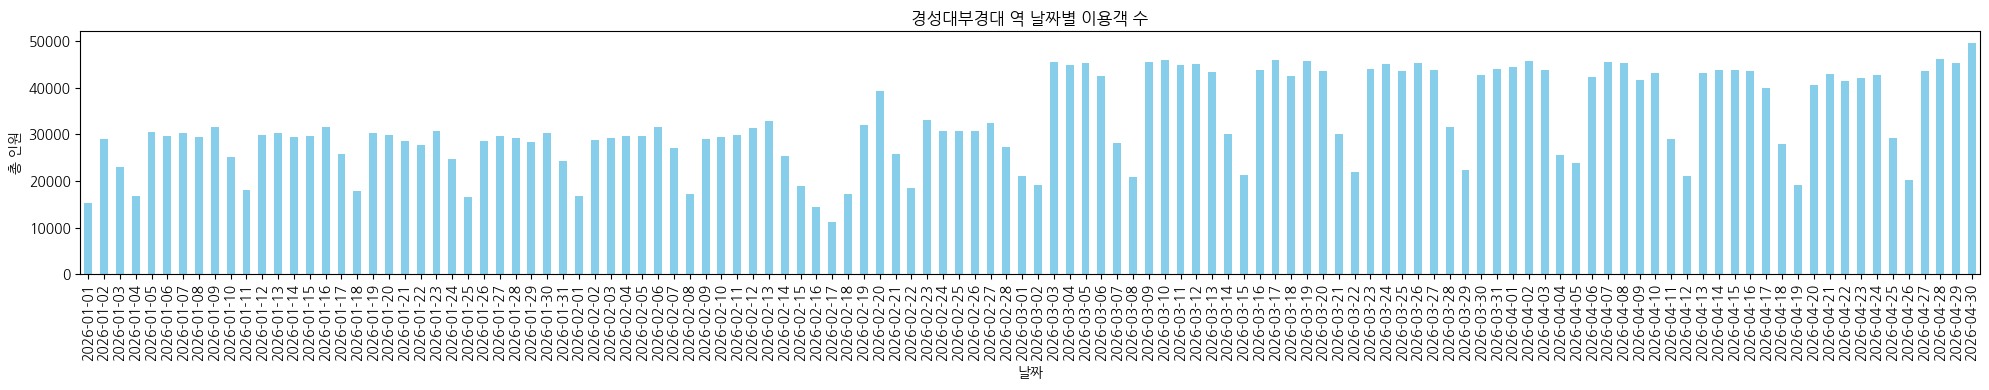

In [4]:
# 경성대부경대의 날짜별 total을 plot 의 bar로 표현하라.

import matplotlib.pyplot as plt

# --- 한글 폰트 설정 추가 ---
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
# ------------------------

# (이후 기존 코드)
station_data = df[df['name'] == '경성대부경대'].copy()
daily_total = station_data.groupby('date')['total'].sum()

plt.figure(figsize=(20, 4))
daily_total.plot(kind='bar', color='skyblue')

plt.title('경성대부경대 역 날짜별 이용객 수')
plt.xlabel('날짜')
plt.ylabel('총 인원')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [5]:
# !pip install squarify

Text(0.2, 0.4, '한글')

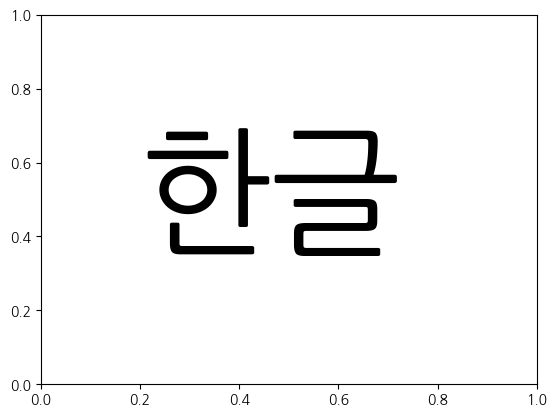

In [6]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [7]:
mdata = gdata.groupby('name').sum().reset_index()
tdata = mdata[['name','total']]
tdata

,name,total
0,가야,859904
1,감전,945880
2,강서구청,743507
3,개금,1977368
4,거제,1407286
...,...,...
103,토성,2133902
104,하단,4438206
105,해운대,3565397
106,호포,303301


In [9]:
total = tdata.sort_values('total', ascending=False)
total = total.head(20)
total

,name,total
70,서면,15442639
83,연산,6546162
61,부산역,5854705
65,사상,5529064
72,센텀시티,4971878
36,동래,4759891
23,남포,4453665
104,하단,4438206
88,자갈치,4340249
33,덕천,4305480


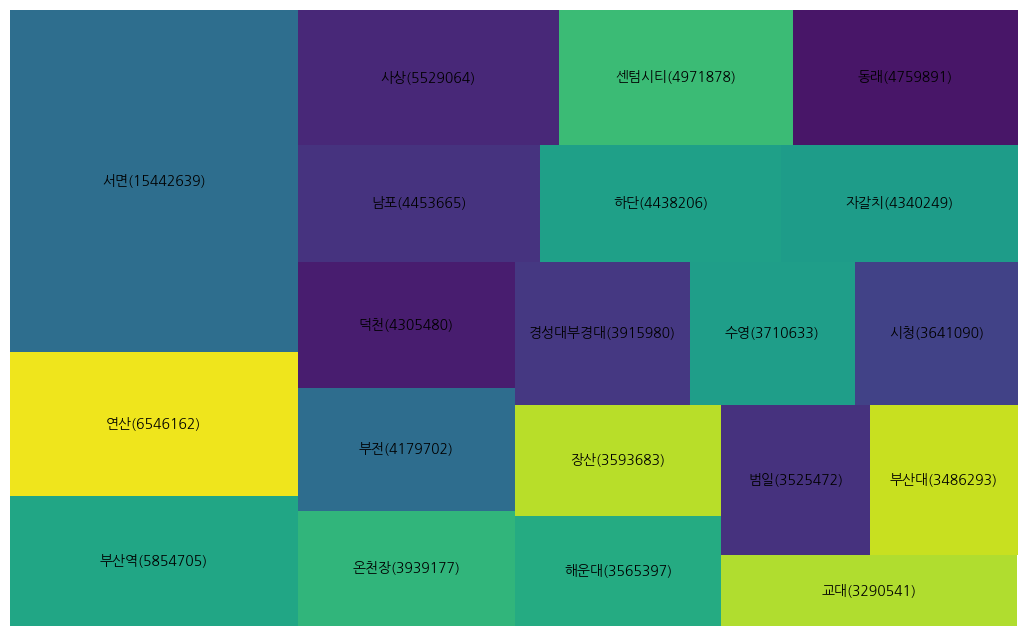

In [10]:
import squarify as sq
plt.figure(figsize=(13,8))
sq.plot(sizes=total['total'], label=[ f"{n}({t})"for n, t in zip(total['name'],total['total'])])
plt.rcParams['font.size'] = 10
plt.rcParams['text.color'] = 'white'
plt.gca().invert_yaxis() # y 축뒤집기
plt.axis("off") # 축 인덱스 끄기
plt.show()

# # 1. 이전 셀([35]번 셀)에서 구한 result 변수를 total 데이터프레임으로 변환
# total = result.reset_index()
# total.columns = ['name', 'total']

# # 2. 한글 폰트 설정 (글자 깨짐 방지)
# plt.rcParams['font.family'] = 'NanumGothic'

# # 3. 트리맵 그리기
# plt.figure(figsize=(16, 9))
# sq.plot(sizes=total['total'], 
#         label=[f"{n}\n({t:,})" for n, t in zip(total['name'], total['total'])], 
#         alpha=0.7)

# plt.rcParams['font.size'] = 12
# plt.rcParams['text.color'] = 'black' # 흰색 배경이면 'black'으로 설정하세요
# plt.axis("off") 
# plt.show()

In [11]:
total = tdata.sort_values('total')

In [12]:
# 1.컬럼명을 역명 -> num, name, date, week, type, total
# 2.1월1일 부터 ~ 4월30일까지 해당역에 타고 내린 모든 total을 집계하라.
# 3.sort 내림차순, 어느역이 가장 많이 타고내렸다.

import pandas as pd

# 1. 파일 다시 로드 (원본 상태로 되돌리기 위해 필수)
file_path = './dataset/일별역별시간대별승하차202604.csv'
df = pd.read_csv(file_path, encoding="EUC-KR")

# 2. 컬럼명 지정 (데이터의 실제 개수와 맞아야 합니다)
# 캡처 화면을 보니 원본 데이터가 총 30개의 컬럼을 가지고 있습니다.
new_columns = ['num', 'name', 'date', 'week', 'type', 'total', 
               '01시-02시', '02시-03시', '03시-04시', '04시-05시', 
               '05시-06시', '06시-07시', '07시-08시', '08시-09시', 
               '09시-10시', '10시-11시', '11시-12시', '12시-13시', 
               '13시-14시', '14시-15시', '15시-16시', '16시-17시', 
               '17시-18시', '18시-19시', '19시-20시', '20시-21시', 
               '21시-22시', '22시-23시', '23시-24시', '24시-01시']

df.columns = new_columns

# 3. 날짜 변환 및 집계
df['date'] = pd.to_datetime(df['date'])

# 역별로 타고 내린 total 집계
station_total = df.groupby('name')['total'].sum()

# 4. 내림차순 정렬 및 결과 출력
result = station_total.sort_values(ascending=False)

print("가장 많이 이용한 역 순위:")
print(result.head(10)) # 상위 10개만 먼저 확인해보세요

# 가장 많이 타고 내린 역 출력 (index 0이 1등입니다)
print(f"\n가장 많이 이용한 역은 '{result.index[0]}'역이며, 총 {result.iloc[0]:,}명입니다.")

가장 많이 이용한 역 순위:
name
서면      15442639
연산       6546162
부산역      5854705
사상       5529064
센텀시티     4971878
동래       4759891
남포       4453665
하단       4438206
자갈치      4340249
덕천       4305480
Name: total, dtype: int64

가장 많이 이용한 역은 '서면'역이며, 총 15,442,639명입니다.


In [13]:
df

,num,name,date,week,type,total,01시-02시,02시-03시,03시-04시,04시-05시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시-01시
0,95,다대포해수욕장,2026-01-01,목,승차,7526,0,0,1,11,...,371,275,315,239,110,96,66,55,7,0
1,95,다대포해수욕장,2026-01-01,목,하차,7357,0,0,1,0,...,238,330,246,139,129,101,88,67,52,44
2,95,다대포해수욕장,2026-01-02,금,승차,4135,0,0,0,28,...,325,290,300,246,116,81,78,74,19,1
3,95,다대포해수욕장,2026-01-02,금,하차,3177,0,0,0,1,...,240,306,296,270,204,127,105,108,84,53
4,95,다대포해수욕장,2026-01-03,토,승차,4114,1,0,0,17,...,392,374,326,208,151,107,111,68,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26875,414,안평,2026-04-28,화,하차,2177,0,0,0,0,...,154,161,188,167,137,88,68,80,25,12
26876,414,안평,2026-04-29,수,승차,2260,0,0,1,7,...,141,158,212,170,56,46,19,14,6,0
26877,414,안평,2026-04-29,수,하차,2171,0,0,1,1,...,142,136,198,179,101,79,74,75,49,23
26878,414,안평,2026-04-30,목,승차,2287,0,0,0,4,...,154,191,225,195,60,42,19,12,9,0


## 서울 2호선 지하철 데이터 분석

In [16]:
# 현재 df는 서울 2호선 데이터가 들어있으므로, 바로 name별 합계를 구합니다.
# 'name' 컬럼은 아까 rename을 통해 설정해두셨습니다.
# mdata = df.groupby('name')['total'].sum().reset_index()

# # 필요한 컬럼만 추출
# tdata = mdata[['name', 'total']]

# # 결과 확인
# print(tdata.head())

# 1. 현재 로드된 df를 사용하여 역별 합계 계산
# 'name' 컬럼별로 'total'을 합산합니다.
mdata = df.groupby('name')['total'].sum().reset_index()

# 2. 필요한 컬럼(name, total)만 추출
tdata = mdata[['name', 'total']]

# 3. 데이터 확인
tdata

,name,total
0,강남,713173166
1,강변,64711713
2,강변(동서울터미널),242603402
3,건대입구,338607905
4,교대,50955617
...,...,...
57,충정로,15175351
58,충정로(경기대입구),70733429
59,한양대,89736278
60,합정,270712774


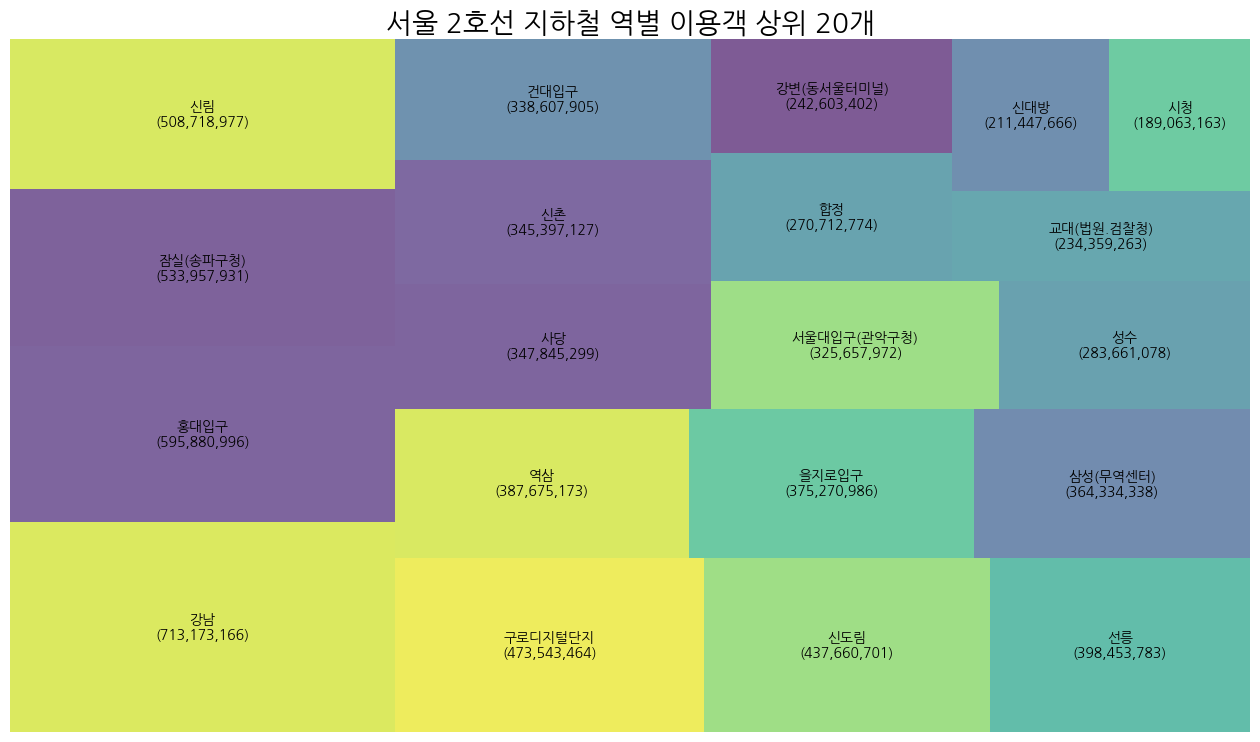

In [17]:
import squarify as sq
import matplotlib.pyplot as plt

# 1. 상위 20개 데이터 추출
top20 = tdata.sort_values('total', ascending=False).head(20)

# 2. 그래프 설정
plt.figure(figsize=(16, 9))
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 10
plt.rcParams['text.color'] = 'black'

# 3. 트리맵 시각화
sq.plot(sizes=top20['total'], 
        label=[f"{n}\n({t:,})" for n, t in zip(top20['name'], top20['total'])], 
        alpha=0.7)

plt.title('서울 2호선 지하철 역별 이용객 상위 20개', fontsize=20)
plt.axis("off")
plt.show()